In [8]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.12.0.dev20260408+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5050 Laptop GPU
Using device: cuda


In [9]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from tqdm import tqdm

In [10]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
from PIL import Image, UnidentifiedImageError

DATA_DIR    = "./dataset"
BATCH_SIZE  = 64
NUM_EPOCHS  = 10
LR          = 1e-4
IMG_SIZE    = 224
VAL_SPLIT   = 0.2

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class SafeImageFolder(ImageFolder):
    def __getitem__(self, index):
        try:
            return super().__getitem__(index)
        except (UnidentifiedImageError, OSError):
            return self.__getitem__((index + 1) % len(self))

full_dataset = SafeImageFolder(DATA_DIR, transform=train_transforms)

val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset = SafeImageFolder(DATA_DIR, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

CLASS_NAMES = full_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Clase găsite ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Train: {train_size} imagini | Val: {val_size} imagini")

Clase găsite (20): ['airplane', 'ambulance', 'bicycle', 'boat', 'bus', 'car', 'fire_truck', 'helicopter', 'hovercraft', 'jet_ski', 'kayak', 'motorcycle', 'rickshaw', 'scooter', 'segway', 'skateboard', 'tractor', 'truck', 'unicycle', 'van']
Train: 2944 imagini | Val: 736 imagini


In [11]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.fc.in_features, NUM_CLASSES)
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam([
    {"params": list(model.parameters())[:-2], "lr": 1e-4},
    {"params": model.fc.parameters(),          "lr": 1e-3},
])

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

print(f"Model pe: {device}")

Model pe: cuda


In [12]:
print(next(model.parameters()).device)

images, labels = next(iter(train_loader))
print(f"Batch pe: {images.device}")
images = images.to(device)
print(f"Batch după .to(device): {images.device}")

cuda:0
Batch pe: cpu
Batch după .to(device): cuda:0


In [7]:
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_losses.append(running_loss / len(train_loader))
    train_accs.append(100. * correct / total)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss    += loss.item()
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(100. * val_correct / val_total)
    scheduler.step()

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss: {train_losses[-1]:.4f} Acc: {train_accs[-1]:.1f}% | "
          f"Val Loss: {val_losses[-1]:.4f} Acc: {val_accs[-1]:.1f}%")

Epoch 1/10 [Train]:   2%|▏         | 1/46 [00:05<04:06,  5.48s/it]d:\Facultate\An3Sem2\SI\Proiect_DeepLearning_Masini\venv\Lib\site-packages\PIL\Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
Epoch 1/10 [Train]:  61%|██████    | 28/46 [02:41<01:43,  5.76s/it]


KeyboardInterrupt: 

In [ ]:
checkpoint = torch.load("model.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print("✅ Model încărcat!")

✅ Model încărcat!


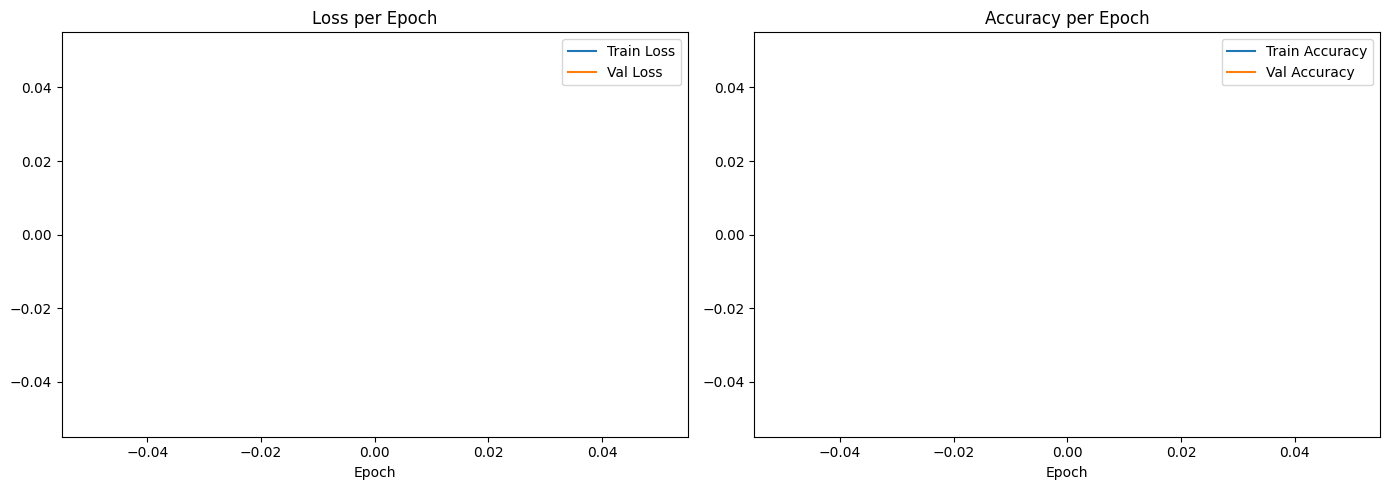

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Train Loss")
ax1.plot(val_losses,   label="Val Loss")
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(train_accs, label="Train Accuracy")
ax2.plot(val_accs,   label="Val Accuracy")
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

In [15]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

              precision    recall  f1-score   support

    airplane       0.97      1.00      0.98        29
   ambulance       1.00      0.97      0.99        35
     bicycle       0.92      0.96      0.94        23
        boat       1.00      0.98      0.99        42
         bus       0.95      1.00      0.97        36
         car       1.00      0.98      0.99        46
  fire_truck       0.97      0.90      0.94        40
  helicopter       1.00      1.00      1.00        39
  hovercraft       0.97      0.97      0.97        36
     jet_ski       0.93      1.00      0.96        27
       kayak       0.97      0.95      0.96        38
  motorcycle       1.00      1.00      1.00        33
    rickshaw       1.00      1.00      1.00        41
     scooter       0.97      1.00      0.99        38
      segway       0.96      0.96      0.96        53
  skateboard       1.00      0.97      0.98        32
     tractor       1.00      1.00      1.00        39
       truck       0.94    

In [ ]:
torch.save({
    "model_state_dict": model.state_dict(),
    "class_names":      CLASS_NAMES,
    "num_classes":      NUM_CLASSES,
}, "model.pth")

print("Model salvat în model.pth ✅")

Model salvat în model.pth ✅


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io
import torch
import torch.nn.functional as F

uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='Incarca Poza'
)
output = widgets.Output()

def on_upload_change(change):
    with output:
        clear_output()
        if uploader.value:
            try:
                uploaded_file = uploader.value[0]
                content = uploaded_file.content
            except KeyError:
                content = list(uploader.value.values())[0]['content']

            img = Image.open(io.BytesIO(content)).convert('RGB')
            display(img.resize((250, 250)))
            
            input_tensor = val_transforms(img).unsqueeze(0).to(device)
            
            model.eval()
            with torch.no_grad():
                out_tensor = model(input_tensor)
                probs = F.softmax(out_tensor, dim=1)
                prob, predicted = torch.max(probs, 1)
                
            car_model = CLASS_NAMES[predicted[0].item()]
            confidence = prob[0].item() * 100
            
            print("-" * 30)
            print(f"Model Prezis: {car_model.upper()}")
            print(f"Nivel de Incredere: {confidence:.2f}%")
            print("-" * 30)
            
            uploader.value.clear()

uploader.observe(on_upload_change, names='value')

display(widgets.VBox([uploader, output]))